# Retail and Customer Analytics

## Project Overview 

This notebook analyses the Olist Brazilian e-commerce dataset using Python and pandas.
The purpose of the analysis is to:

- validate the quality and structure of the source data;
- calculate delivered-order KPIs;
- analyse monthly merchandise value;
- measure repeat purchasing;
- identify leading product categories;
- understand the geographical distribution of customers.

Merchandise value refers to product prices and excludes freight charges.

In [2]:
# libraries used for data analysis, file paths and charts 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

## 1. Locate the source data

The raw CSV files are stored locally in the `data/raw` folder. `Path` is used to construct the folder location without hardcoding a private computer-specific path.

The raw files are excluded from GitHub because of their size, but their source and required filenames are documented in `data/README.md`.

In [3]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

## 2. Load and inspect orders
The orders table contains one row per order. It includes the order status and important timestamps such as purchase, approval and delivery dates.

The first checks confirm that the file loaded correctly and help identify unexpected columns, missing values and incorrect data types.

In [3]:
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")

# Remove completely empty columns accidentally created during CSV export
orders = orders.loc[
    :,
    ~orders.columns.str.startswith("Unnamed")
]

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02/10/2017 10:56,02/10/2017 11:07,04/10/2017 19:55,10/10/2017 21:25,18/10/2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24/07/2018 20:41,26/07/2018 03:24,26/07/2018 14:31,07/08/2018 15:27,13/08/2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08/08/2018 08:38,08/08/2018 08:55,08/08/2018 13:50,17/08/2018 18:06,04/09/2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18/11/2017 19:28,18/11/2017 19:45,22/11/2017 13:39,02/12/2017 00:28,15/12/2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13/02/2018 21:18,13/02/2018 22:20,14/02/2018 19:46,16/02/2018 18:17,26/02/2018 00:00


In [5]:
orders.shape

(99441, 8)

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


### Convert order dates

CSV files usually load dates as text. These columns must be converted to datetime values before Python can group orders by month or perform time-based analysis.

The dataset contains mixed date formats, so `format="mixed"` and `dayfirst=True` are used. Invalid dates are converted to missing values rather than stopping the notebook.

In [7]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders[date_columns] = orders[date_columns].apply(
    lambda column: pd.to_datetime(
        column,
        format="mixed",
        dayfirst=True,
        errors="coerce"
    )
)

In [8]:
orders["order_purchase_timestamp"].dtype

dtype('<M8[ns]')

### Validate orders

Missing-value counts are used to identify incomplete fields. The order-status distribution shows how many orders were delivered, cancelled or remained at another stage.

A separate check identifies orders marked as delivered even though their customer-delivery date is missing. This is a small but important data-quality inconsistency.

In [9]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [11]:
orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isnull())
].shape[0]

8

## 3. Load and inspect order items

The order-items table contains one row per product within an order. One order may therefore appear several times.

This table provides product IDs, seller IDs, item prices and freight values. Item prices are later aggregated to calculate merchandise value.

In [12]:
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")

In [13]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,19/09/2017 09:45,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,03/05/2017 11:05,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,18/01/2018 14:48,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,15/08/2018 10:10,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,13/02/2017 13:57,199.90,18.14


In [14]:
order_items.shape

(112650, 7)

In [15]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


### Convert and validate the shipping deadline

The shipping deadline is converted from text to datetime so it can be used correctly in any future fulfilment or delivery analysis.

In [16]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [17]:
order_items['shipping_limit_date'].dtype

dtype('<M8[ns]')

In [18]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

## 4. Load and inspect customers

The customer table contains two different customer identifiers:

- `customer_id` links one customer record to one order;
- `customer_unique_id` identifies the same real customer across multiple orders.

The unique identifier is therefore used for repeat-customer and geographical analysis.

In [19]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")

In [20]:
customers.shape

(99441, 5)

In [21]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [22]:
customers['customer_unique_id'].nunique()

96096

In [23]:
customers['customer_unique_id'].value_counts().head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
63cfc61cee11cbe306bff5857d00bfe4     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
de34b16117594161a6a89c50b289d35a     6
dc813062e0fc23409cd255f7f53c7074     6
Name: count, dtype: int64

## 5. Load and inspect products

The products table provides product categories, dimensions, weight and descriptive attributes.

Missing category names must be handled carefully because pandas normally excludes missing groups from category summaries.

In [24]:
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")

In [25]:
products.shape

(32951, 9)

In [26]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [27]:
missing_product_categories = (
    products["product_category_name"]
    .isnull()
    .sum()
)

print(
    "Products originally missing a category:",
    missing_product_categories
)

Products originally missing a category: 610


In [28]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')

In [29]:
products['product_category_name'].isnull().sum()

np.int64(0)

## 6. Calculate order value and delivered-order KPIs

An order may contain several items. The item prices are therefore grouped by `order_id` and summed to produce one merchandise-value figure per order.

Freight is excluded because this project defines merchandise value as product price only.

In [30]:
order_value = (
    order_items
    .groupby('order_id', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'order_value'})
)

In [31]:
order_value.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [32]:
all_order_aov = order_value["order_value"].mean()

print(
    f"Average order value across all orders: "
    f"{all_order_aov:,.2f}"
)

Average order value across all orders: 137.75


### Delivered-order KPIs

Only delivered orders are used for the final sales KPIs. This prevents cancelled, unavailable and unfinished orders from contributing to realised merchandise value.

In [33]:
delivered_orders = orders[
    orders['order_status'] == 'delivered'
][['order_id']]

delivered_order_value = delivered_orders.merge(
    order_value,
    on='order_id',
    how='inner'
)


In [34]:
delivered_order_count = (
    delivered_order_value["order_id"]
    .nunique()
)

delivered_merchandise_value = (
    delivered_order_value["order_value"]
    .sum()
)

average_delivered_order_value = (
    delivered_order_value["order_value"]
    .mean()
)

print(
    f"Delivered orders: "
    f"{delivered_order_count:,}"
)

print(
    f"Delivered merchandise value: "
    f"R${delivered_merchandise_value:,.2f}"
)

print(
    f"Average delivered order value: "
    f"R${average_delivered_order_value:,.2f}"
)


Delivered orders: 96,478
Delivered merchandise value: R$13,221,498.11
Average delivered order value: R$137.04


## 7. Analyse monthly delivered merchandise value

Delivered orders are joined to their items so that item prices can be grouped by purchase month.

This analysis shows seasonal patterns, identifies the strongest month and measures month-on-month changes.

In [35]:
monthly_sales = (
    orders[orders['order_status'] == 'delivered']
    .merge(order_items, on='order_id', how='inner')
)

monthly_sales['month'] = (
    monthly_sales['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)

monthly_trend = (
    monthly_sales
    .groupby('month', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'merchandise_value'})
)

monthly_trend.head()

,month,merchandise_value
0,2016-09-01,134.97
1,2016-10-01,40325.11
2,2016-12-01,10.90
3,2017-01-01,111798.36
4,2017-02-01,234223.40


### Monthly delivered merchandise value

This line chart shows how delivered merchandise value changed over time.

The horizontal axis represents the purchase month, while the vertical axis represents the total product value from delivered orders. Freight charges are excluded.

The values are displayed in millions to make the chart easier to read. This visual helps identify growth patterns, seasonal changes and unusually strong or weak months.

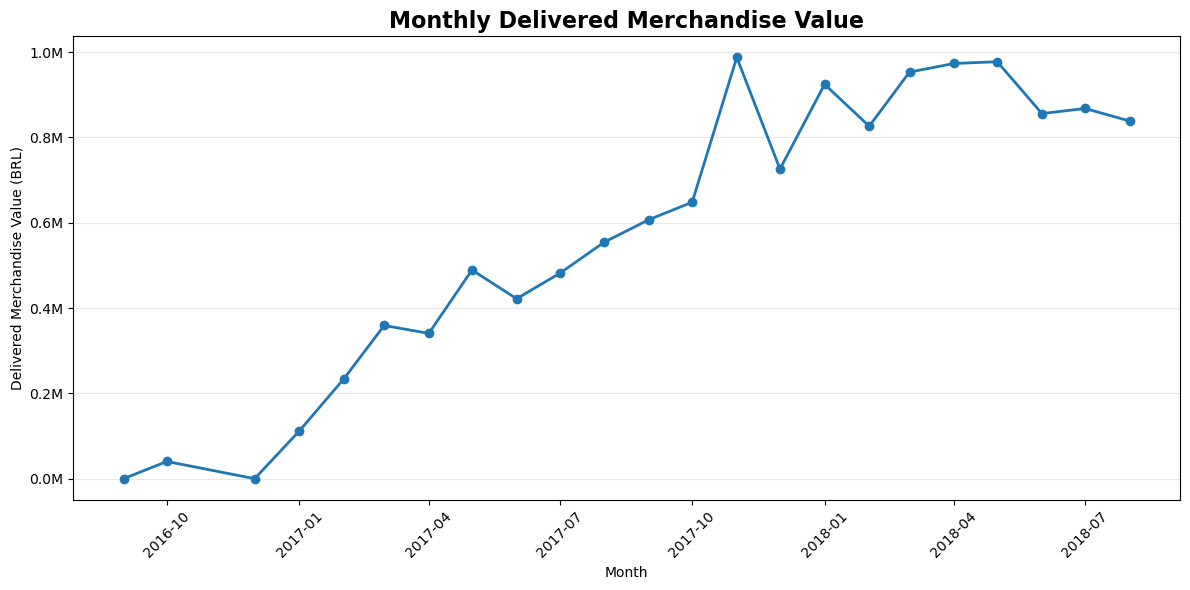

In [36]:

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_trend['month'],
    monthly_trend['merchandise_value'],
    marker='o',
    linewidth=2
)

plt.title(
    'Monthly Delivered Merchandise Value',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel("Delivered Merchandise Value (BRL)")

plt.grid(axis='y', alpha=0.3)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M')
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Identify the strongest sales month

The following calculation finds the month with the highest delivered merchandise value.

`idxmax()` identifies the row containing the maximum value, while `.loc[]` returns the complete row with the month and merchandise value.

In [37]:
strongest_month = monthly_trend.loc[
    monthly_trend["merchandise_value"].idxmax()
]

strongest_month

month                2017-11-01 00:00:00
merchandise_value              987765.37
Name: 13, dtype: object

### Calculate month-on-month growth

Month-on-month growth measures how much delivered merchandise value increased or decreased compared with the previous month.

The analysis starts in January 2017 because the earliest 2016 data is incomplete and could produce misleading percentage changes.

A positive percentage means merchandise value increased. A negative percentage means it decreased.

In [38]:
monthly_trend_2017 = monthly_trend[
    monthly_trend["month"] >= "2017-01-01"
].copy()
monthly_trend_2017["growth_pct"] = (
    monthly_trend_2017["merchandise_value"]
    .pct_change() * 100
)

monthly_trend_2017[
    ["month", "merchandise_value", "growth_pct"]
].round(2)

,month,merchandise_value,growth_pct
3,2017-01-01,111798.36,NaN
4,2017-02-01,234223.40,109.51
5,2017-03-01,359198.85,53.36
6,2017-04-01,340669.68,-5.16
7,2017-05-01,489338.25,43.64
8,2017-06-01,421923.37,-13.78
9,2017-07-01,481604.52,14.15
10,2017-08-01,554699.70,15.18
11,2017-09-01,607399.67,9.50
12,2017-10-01,648247.65,6.73


### Identify the largest monthly increase and decrease

The maximum growth percentage identifies the strongest month-on-month increase. The minimum growth percentage identifies the largest decline.

These results help highlight periods that may require further investigation into promotions, seasonality, product availability or operational performance.

In [39]:
best_growth_month = monthly_trend_2017.loc[
    monthly_trend_2017["growth_pct"].idxmax()
]

worst_growth_month = monthly_trend_2017.loc[
    monthly_trend_2017["growth_pct"].idxmin()
]

print(
    f"Largest monthly increase: "
    f"{best_growth_month['month']:%B %Y}, "
    f"{best_growth_month['growth_pct']:.2f}%"
)

print(
    f"Largest monthly decrease: "
    f"{worst_growth_month['month']:%B %Y}, "
    f"{worst_growth_month['growth_pct']:.2f}%"
)

Largest monthly increase: February 2017, 109.51%
Largest monthly decrease: December 2017, -26.50%


## 8. Customer repeat-purchase analysis

`customer_unique_id` identifies the same real customer across different orders.

The following analysis counts how many customer records belong to each unique customer. Customers appearing more than once are classified as repeat customers.

This produces a historical repeat-purchase rate for the complete dataset. It is not a time-based cohort-retention rate.

In [40]:
customer_order_counts = (
    customers["customer_unique_id"]
    .value_counts()
)

repeat_customers = (
    customer_order_counts > 1
).sum()

one_time_customers = (
    customer_order_counts == 1
).sum()

unique_customers = (
    customers["customer_unique_id"]
    .nunique()
)

repeat_purchase_rate = (
    repeat_customers / unique_customers
) * 100

average_orders_per_customer = (
    customer_order_counts.mean()
)

customer_summary = pd.DataFrame({
    "metric": [
        "Unique customers",
        "Repeat customers",
        "One-time customers",
        "Repeat purchase rate (%)",
        "Average orders per customer"
    ],
    "value": [
        unique_customers,
        repeat_customers,
        one_time_customers,
        round(repeat_purchase_rate, 2),
        round(average_orders_per_customer, 2)
    ]
})

customer_summary

,metric,value
0,Unique customers,96096.00
1,Repeat customers,2997.00
2,One-time customers,93099.00
3,Repeat purchase rate (%),3.12
4,Average orders per customer,1.03


## 9. Product-category performance

Product-category performance is calculated using delivered order items only. This keeps the analysis consistent with the delivered merchandise-value KPIs and the Power BI dashboard.

The delivered items are joined to the products table using `product_id`. Merchandise value is then summed for each category and ranked from highest to lowest.

In [41]:
category_sales = (
    monthly_sales
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
)

category_sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,month,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:00,29.99,8.72,2017-10-01,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:00,118.70,22.76,2018-07-01,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:00,159.90,19.22,2018-08-01,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:00,45.00,27.20,2017-11-01,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:00,19.90,8.72,2018-02-01,papelaria


In [42]:
category_sales["price"].sum()

np.float64(13221498.110000001)

In [43]:
top_categories = (
    category_sales
    .groupby(
        "product_category_name",
        as_index=False
    )["price"]
    .sum()
    .rename(
        columns={
            "price": "merchandise_value"
        }
    )
    .sort_values(
        "merchandise_value",
        ascending=False
    )
    .head(10)
)

top_categories

,product_category_name,merchandise_value
12,beleza_saude,1233131.72
67,relogios_presentes,1166176.98
14,cama_mesa_banho,1023434.76
33,esporte_lazer,954852.55
45,informatica_acessorios,888724.61
55,moveis_decoracao,711927.69
73,utilidades_domesticas,615628.69
27,cool_stuff,610204.10
9,automotivo,578966.65
13,brinquedos,471286.48


### Translate product-category names

The original Olist category names are written in Portuguese. The category-translation table is joined to the results so that the final table and chart use English labels.

A left join is used so that a category remains in the analysis even if an English translation is unavailable.

In [44]:
category_translation = pd.read_csv(
    DATA_DIR
    / "product_category_name_translation.csv"
)

top_categories_english = (
    top_categories
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

top_categories_english[
    "product_category_name_english"
] = (
    top_categories_english[
        "product_category_name_english"
    ]
    .fillna(
        top_categories_english[
            "product_category_name"
        ]
    )
)

top_categories_english

,product_category_name,merchandise_value,product_category_name_english
0,beleza_saude,1233131.72,health_beauty
1,relogios_presentes,1166176.98,watches_gifts
2,cama_mesa_banho,1023434.76,bed_bath_table
3,esporte_lazer,954852.55,sports_leisure
4,informatica_acessorios,888724.61,computers_accessories
5,moveis_decoracao,711927.69,furniture_decor
6,utilidades_domesticas,615628.69,housewares
7,cool_stuff,610204.10,cool_stuff
8,automotivo,578966.65,auto
9,brinquedos,471286.48,toys


### Visualise the leading delivered product categories

A horizontal bar chart is used because the category names are relatively long.

The chart compares the ten product categories with the highest delivered merchandise value. Values are divided by one million to make the horizontal scale easier to read.

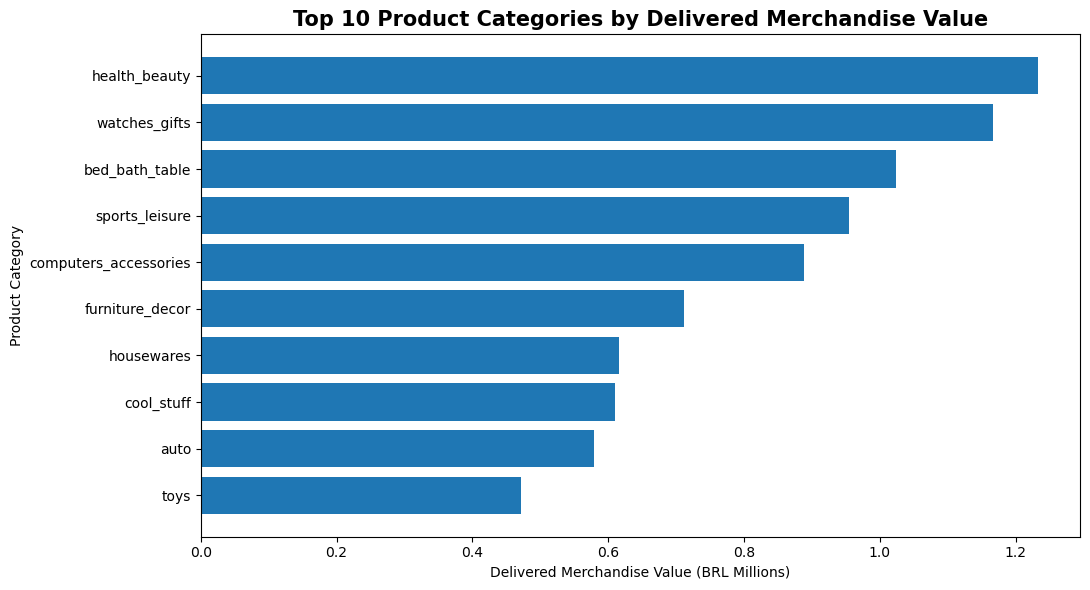

In [45]:
plot_data = (
    top_categories_english
    .sort_values(
        "merchandise_value",
        ascending=True
    )
)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_data[
        "product_category_name_english"
    ],
    plot_data[
        "merchandise_value"
    ] / 1_000_000
)

plt.title(
    "Top 10 Product Categories by "
    "Delivered Merchandise Value",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Delivered Merchandise Value (BRL Millions)"
)
plt.ylabel("Product Category")

plt.subplots_adjust(left=0.28)
plt.tight_layout()
plt.show()

## 10. Customer geography

This analysis counts distinct customers in each Brazilian state using `customer_unique_id`.

Using the unique identifier prevents repeat customers from being counted more than once. The states are ranked by customer count to show where the customer base is concentrated.

In [46]:
state_customers = (
    customers
    .groupby(
        "customer_state",
        as_index=False
    )["customer_unique_id"]
    .nunique()
    .rename(
        columns={
            "customer_unique_id":
            "unique_customers"
        }
    )
    .sort_values(
        "unique_customers",
        ascending=False
    )
)

state_customers.head(10)

,customer_state,unique_customers
25,SP,40302
18,RJ,12384
10,MG,11259
22,RS,5277
17,PR,4882
23,SC,3534
4,BA,3277
6,DF,2075
7,ES,1964
8,GO,1952


### Visualise the largest customer markets

The original dataset uses two-letter state abbreviations. These are mapped to full state names to make the chart easier to understand.

A horizontal bar chart displays the ten states with the most unique customers. This highlights the geographical concentration of the customer base.

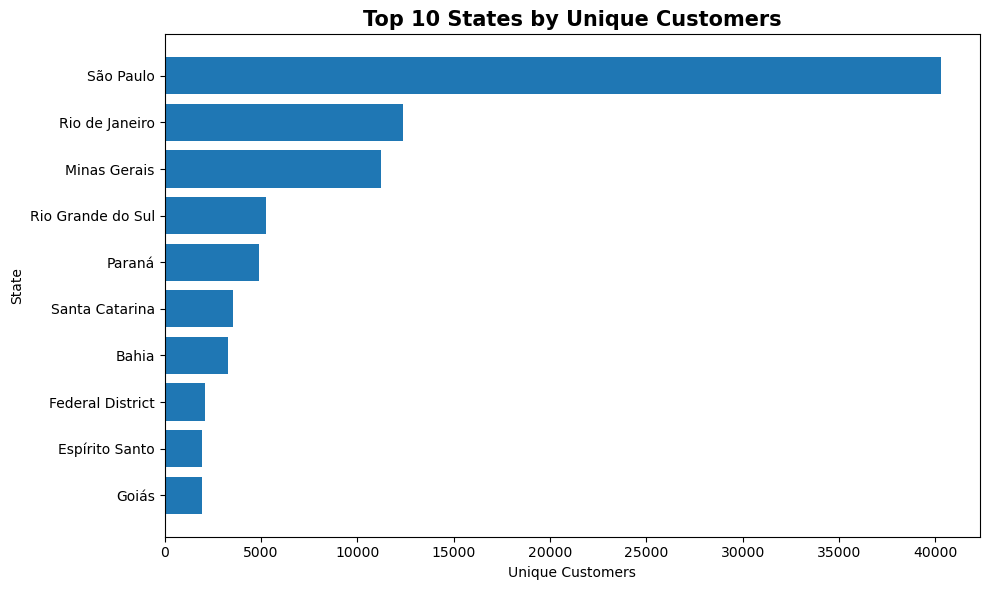

In [47]:
state_name_map = {
    "SP": "São Paulo",
    "RJ": "Rio de Janeiro",
    "MG": "Minas Gerais",
    "RS": "Rio Grande do Sul",
    "PR": "Paraná",
    "SC": "Santa Catarina",
    "BA": "Bahia",
    "DF": "Federal District",
    "ES": "Espírito Santo",
    "GO": "Goiás"
}

state_plot = state_customers.head(10).copy()

state_plot["state_name"] = (
    state_plot["customer_state"]
    .map(state_name_map)
)

state_plot = state_plot.sort_values(
    "unique_customers",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    state_plot["state_name"],
    state_plot["unique_customers"]
)

plt.title(
    "Top 10 States by Unique Customers",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Unique Customers")
plt.ylabel("State")

plt.tight_layout()
plt.show()

## Conclusion

### What I found 

This analysis gave me a clearer picture of how the business performed across orders, customers, product categories and locations.

The dataset contains **96,478 delivered orders**, with a total delivered merchandise value of around **R$13.22 million**. 

The average delivered order value was approximately **R$137.04**.

**November 2017** was the strongest month, generating **R$987,765.37** in delivered merchandise value. The biggest monthly increase happened in **February 2017**, when merchandise value increased by about **109.51%**. The largest decrease occurred in **December 2017**, with a fall of approximately **26.50%**.

Customer retention appears to be an important challenge. There were **96,096 unique customers**, but only **2,997** made more than one purchase. This resulted in a repeat-purchase rate of around **3.12%**.

The product categories contributing the most delivered merchandise value included **health and beauty**, **watches and gifts**, **bed, bath and table**, **sports and leisure**, and **computer accessories**.

Most customers were located in **São Paulo**, followed by **Rio de Janeiro** and **Minas Gerais**. São Paulo had a much larger customer base than any other state.

### What the business could do 

The low repeat-purchase rate suggests that encouraging customers to return should be a priority. The business could consider loyalty rewards, personalised offers or follow-up promotions after a customer’s first order.

High-value product categories should continue to receive close attention because they contribute strongly to merchandise value.

Since São Paulo has the largest customer base, it would make sense to prioritise marketing, delivery performance and customer service in that region.

The strong performance in November 2017 could be studied further to understand whether it was driven by promotions, seasonal demand or particular product categories. The decline in December should also be investigated alongside seasonality, stock availability and delivery performance.

### Limitations

Merchandise value in this analysis includes product prices but does not include freight charges.

The repeat-purchase rate is based on the customer’s activity across the complete dataset. It is not a formal retention rate measured over a fixed period.

The earliest 2016 data appears incomplete, so I focused the main monthly growth comparison on 2017 onwards.

I also found a small number of delivered orders with missing delivery dates and some products with missing category information. These issues should be monitored because they may affect reporting accuracy.